In [5]:
import os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json
import math
import re


In [2]:
# Find all results
RESULTS_DIR = Path("/hpc/home/bfa6/work/github/yapper/experiments/experiment4_multiseed_on_top5_normal/results")
experiments = [p for p in RESULTS_DIR.iterdir() if p.is_dir()]
print(len(experiments))

25


In [3]:
all_results = []

# Get evaluation results if available
for experiment in experiments:
    results_path = experiment / "eval_results.json"
    metadata_path = experiment / "metadata.json"
    
    experiment_data = {
        "experiment_name": experiment.name,
    }

    if metadata_path.exists():
        with open(metadata_path, "r") as f:
            metadata = json.load(f)
        
        experiment_data["max_seq_length"] = metadata.get("max_seq_length")
        experiment_data["lora_rank"] = metadata.get("lora_rank")
        experiment_data["model_name"] = metadata.get("model_name")
        
        if "training_params" in metadata:
            experiment_data["learning_rate"] = metadata["training_params"].get("learning_rate")
            experiment_data["gradient_accumulation_steps"] = metadata["training_params"].get("gradient_accumulation_steps")
        
        # Prioritize metadata for configuration parameters if they exist
        experiment_data["lambda_qa"] = metadata.get("lambda_qa")
        experiment_data["num_qa_samples"] = metadata.get("num_qa_samples")

    if results_path.exists():
        with open(results_path, "r") as f:
            results = json.load(f)
        
        # If lambda_qa or num_qa_samples were not in metadata, get them from results
        if "lambda_qa" not in experiment_data or experiment_data["lambda_qa"] is None:
            experiment_data["lambda_qa"] = results.get("lambda_qa")
        if "num_qa_samples" not in experiment_data or experiment_data["num_qa_samples"] is None:
            experiment_data["num_qa_samples"] = results.get("num_qa_samples")

        experiment_data["avg_qa_accuracy"] = results.get("avg_qa_accuracy")
        experiment_data["avg_length_reward"] = results.get("avg_length_reward")
        experiment_data["avg_compression_ratio"] = results.get("avg_compression_ratio")
        experiment_data["avg_overall_reward"] = results.get("avg_overall_reward")
        
        all_results.append(experiment_data)

results_df = pd.DataFrame(all_results)

In [ ]:
results_df.sort_values(by="avg_qa_accuracy", ascending=False)

,experiment_name,max_seq_length,lora_rank,model_name,learning_rate,gradient_accumulation_steps,lambda_qa,num_qa_samples,avg_qa_accuracy,avg_length_reward,avg_compression_ratio,avg_overall_reward
5,multiseed_top2_lr_5eneg05_rank_8_gradaccum_4_l...,2048,8,unsloth/Qwen3-4B-Instruct-2507,0.00005,4,-0.2,2,0.784,0.744058,4.609023,0.535407
22,multiseed_top5_lr_5eneg05_rank_16_gradaccum_4_...,2048,16,unsloth/Qwen3-4B-Instruct-2507,0.00005,4,-0.5,2,0.751,0.771827,5.269351,0.449606
18,multiseed_top4_lr_1eneg04_rank_8_gradaccum_4_l...,2048,8,unsloth/Qwen3-4B-Instruct-2507,0.00010,4,-0.2,2,0.741,0.469401,2.235751,0.294250
17,multiseed_top4_lr_1eneg04_rank_8_gradaccum_4_l...,2048,8,unsloth/Qwen3-4B-Instruct-2507,0.00010,4,-0.2,2,0.739,0.782160,5.042799,0.522406
16,multiseed_top4_lr_1eneg04_rank_8_gradaccum_4_l...,2048,8,unsloth/Qwen3-4B-Instruct-2507,0.00010,4,-0.2,2,0.720,0.788426,5.252890,0.510332
23,multiseed_top5_lr_5eneg05_rank_16_gradaccum_4_...,2048,16,unsloth/Qwen3-4B-Instruct-2507,0.00005,4,-0.5,2,0.698,0.802976,5.714814,0.406009
20,multiseed_top5_lr_5eneg05_rank_16_gradaccum_4_...,2048,16,unsloth/Qwen3-4B-Instruct-2507,0.00005,4,-0.5,2,0.694,0.789983,5.438455,0.390879
9,multiseed_top3_lr_5eneg05_rank_16_gradaccum_4_...,2048,16,unsloth/Qwen3-4B-Instruct-2507,0.00005,4,-1.0,2,0.684,0.823141,7.172282,0.242970
3,multiseed_top1_lr_1eneg04_rank_16_gradaccum_4_...,2048,16,unsloth/Qwen3-4B-Instruct-2507,0.00010,4,-1.0,2,0.672,0.820922,5.823178,0.222548
21,multiseed_top5_lr_5eneg05_rank_16_gradaccum_4_...,2048,16,unsloth/Qwen3-4B-Instruct-2507,0.00005,4,-0.5,2,0.666,0.848152,7.555091,0.394767


In [9]:
summary = (
    results_df
        .groupby("topx")
        .agg(
            avg_qa_accuracy_mean=("avg_qa_accuracy", "mean"),
            avg_qa_accuracy_std=("avg_qa_accuracy", "std"),
            avg_compression_ratio_mean=("avg_compression_ratio", "mean"),
            avg_compression_ratio_std=("avg_compression_ratio", "std"),
        )
        .sort_values("avg_qa_accuracy_mean", ascending=False)
)

summary


,avg_qa_accuracy_mean,avg_qa_accuracy_std,avg_compression_ratio_mean,avg_compression_ratio_std
topx,,,,
5,0.67800,0.062326,7.023771,2.476876
2,0.64320,0.107581,7.761383,4.127354
3,0.63120,0.042275,8.222897,1.262664
4,0.54020,0.288459,131.620703,279.023749
1,0.39325,0.304963,120.769071,148.335637


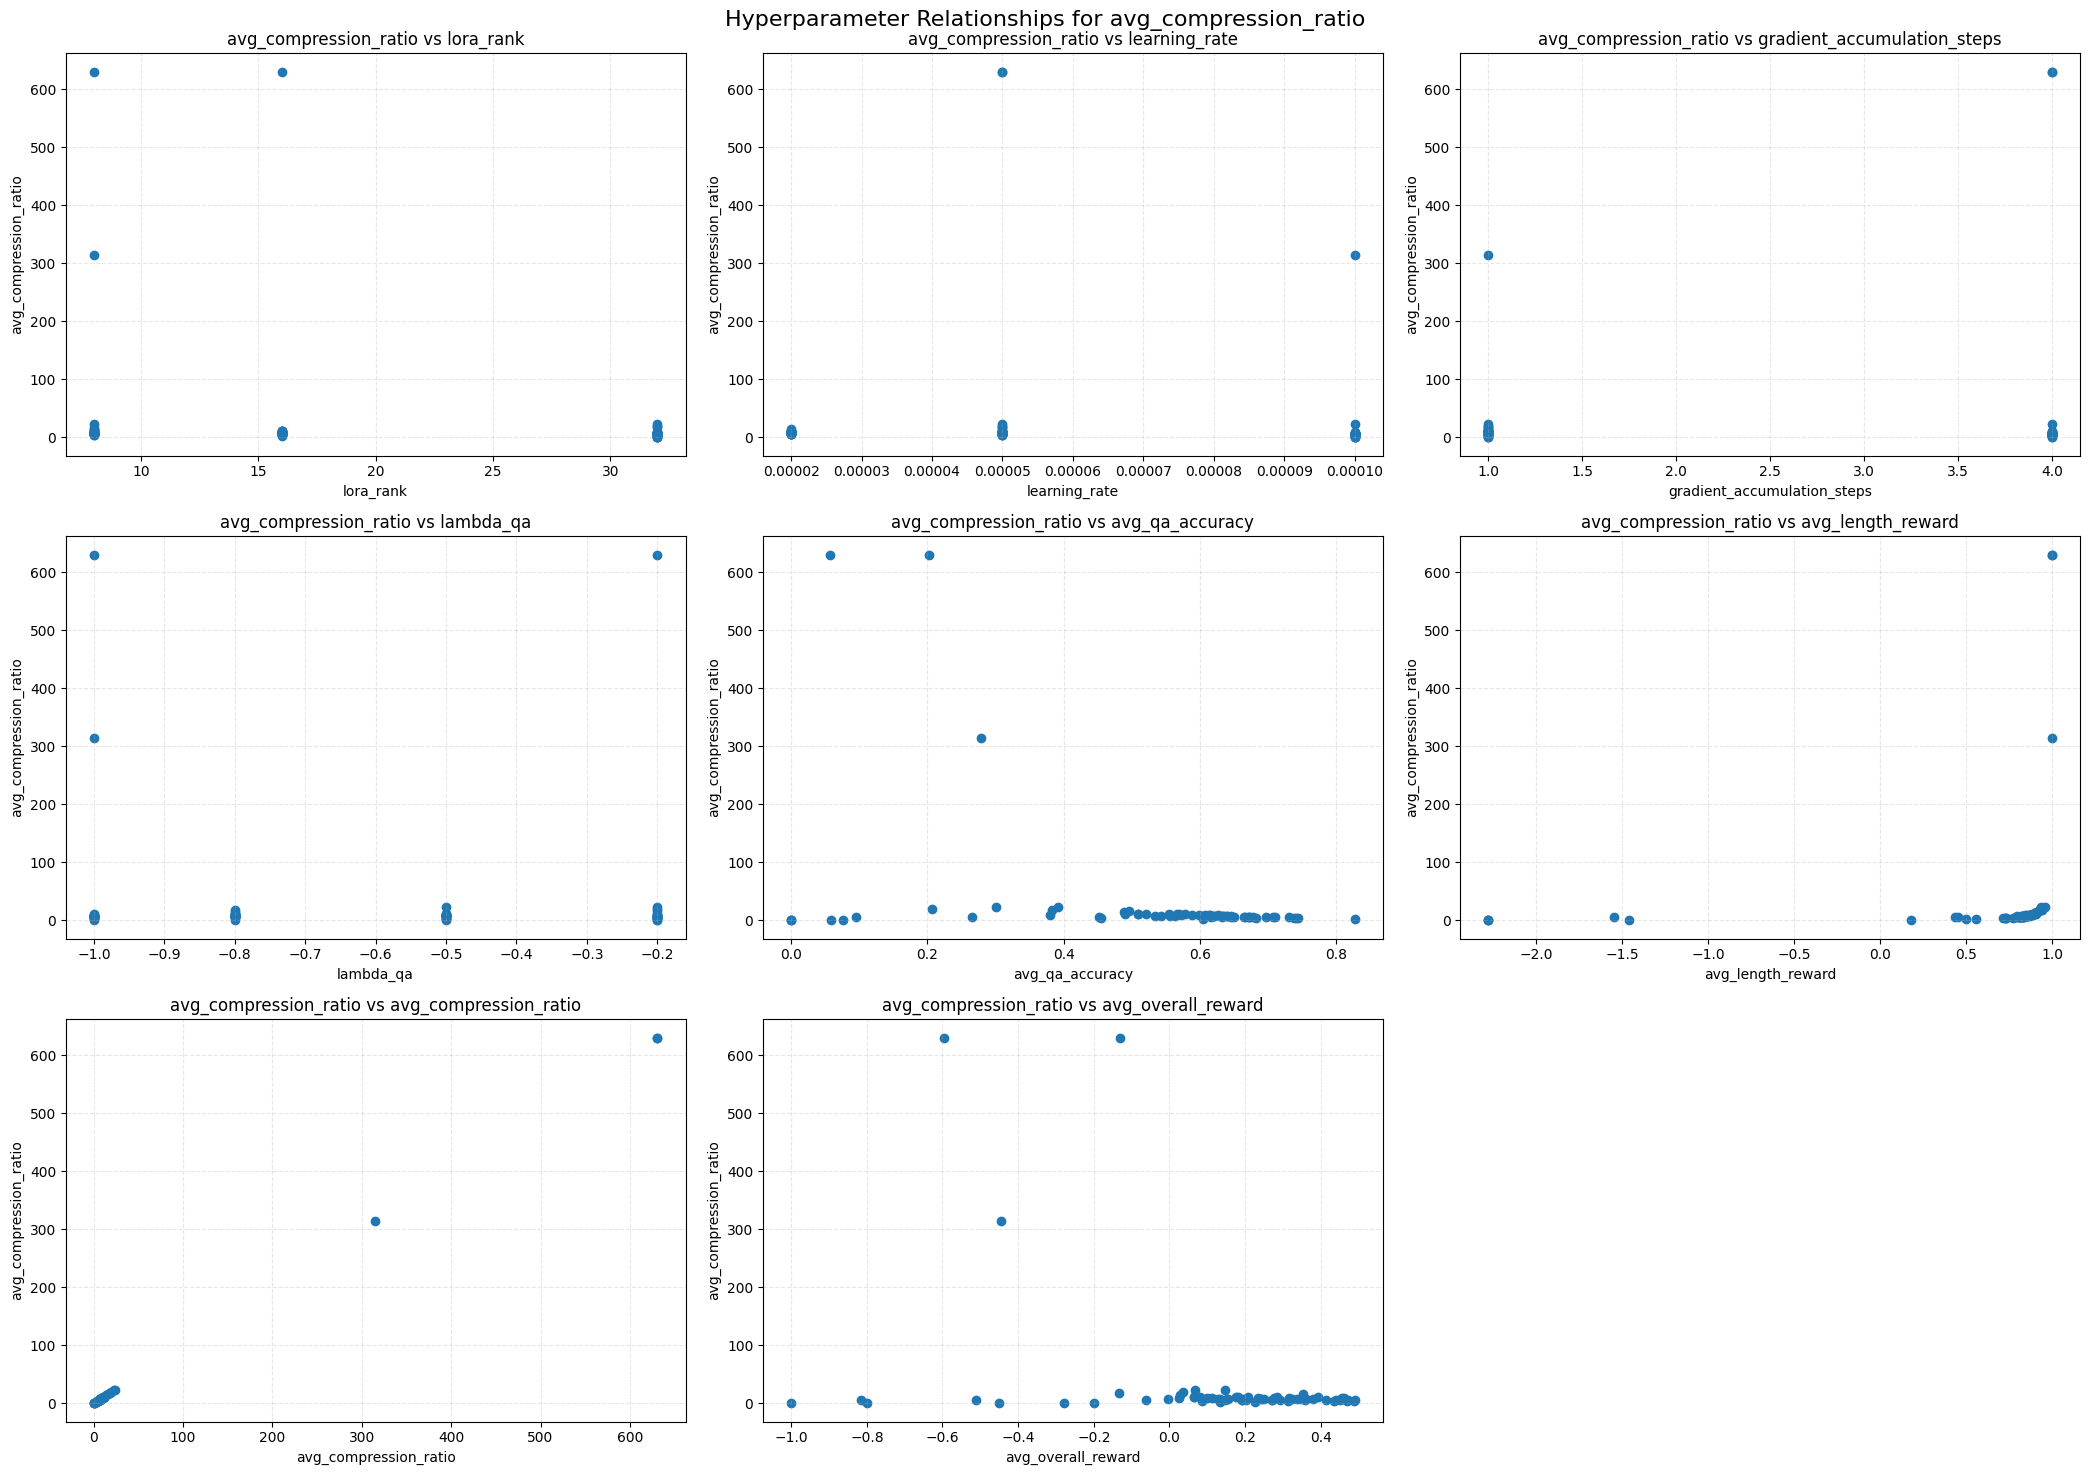

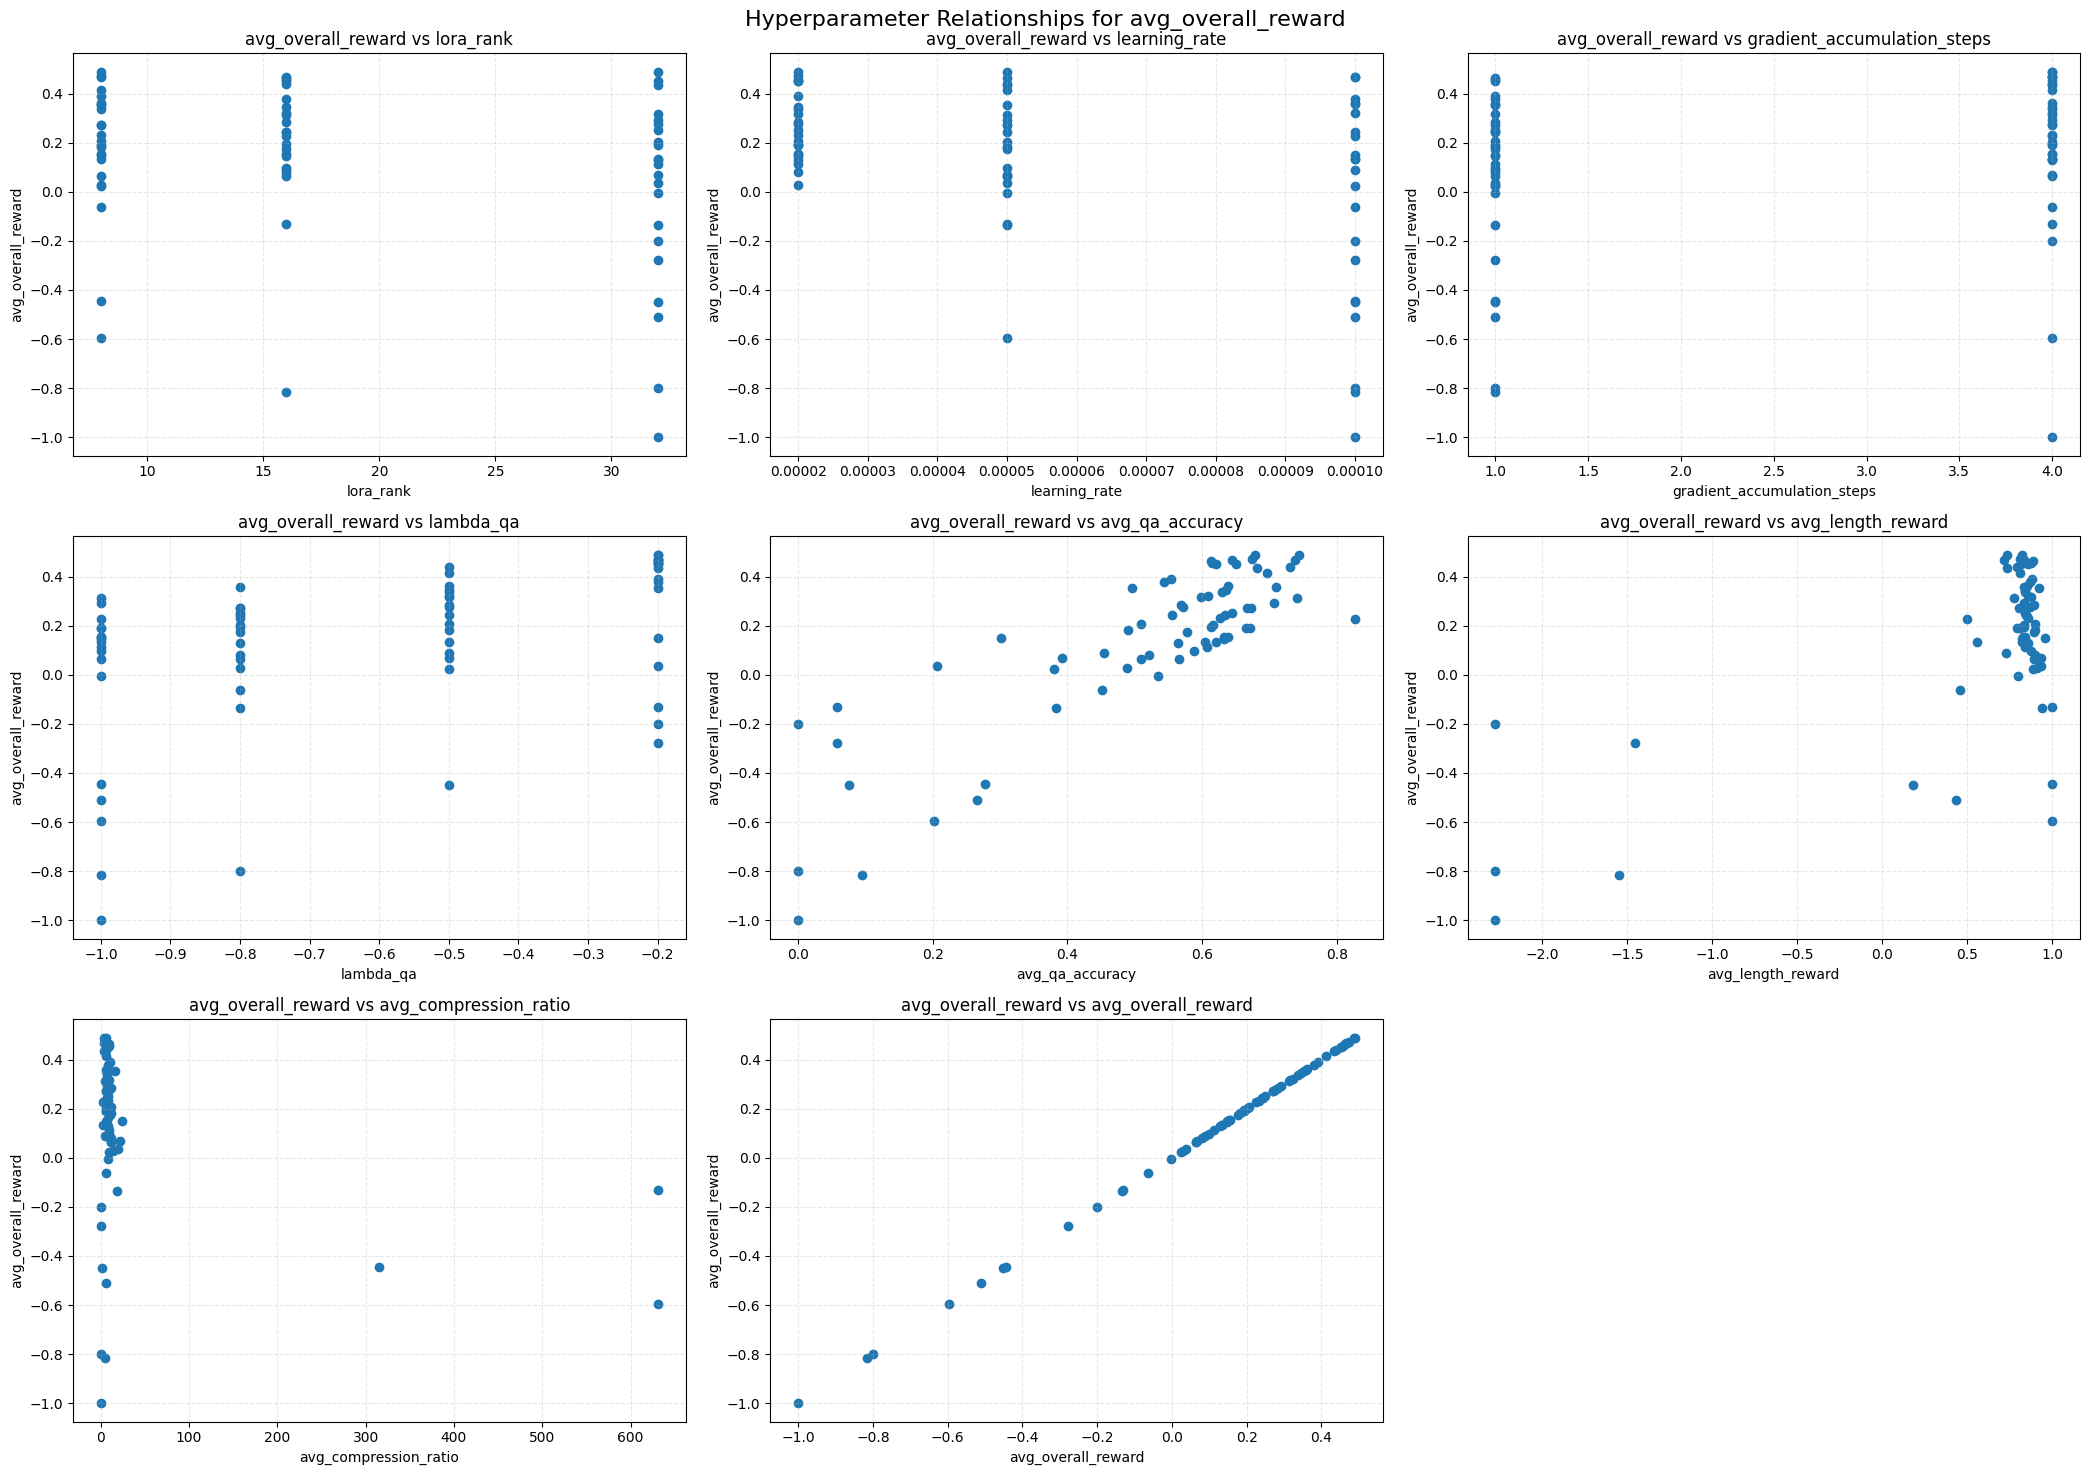

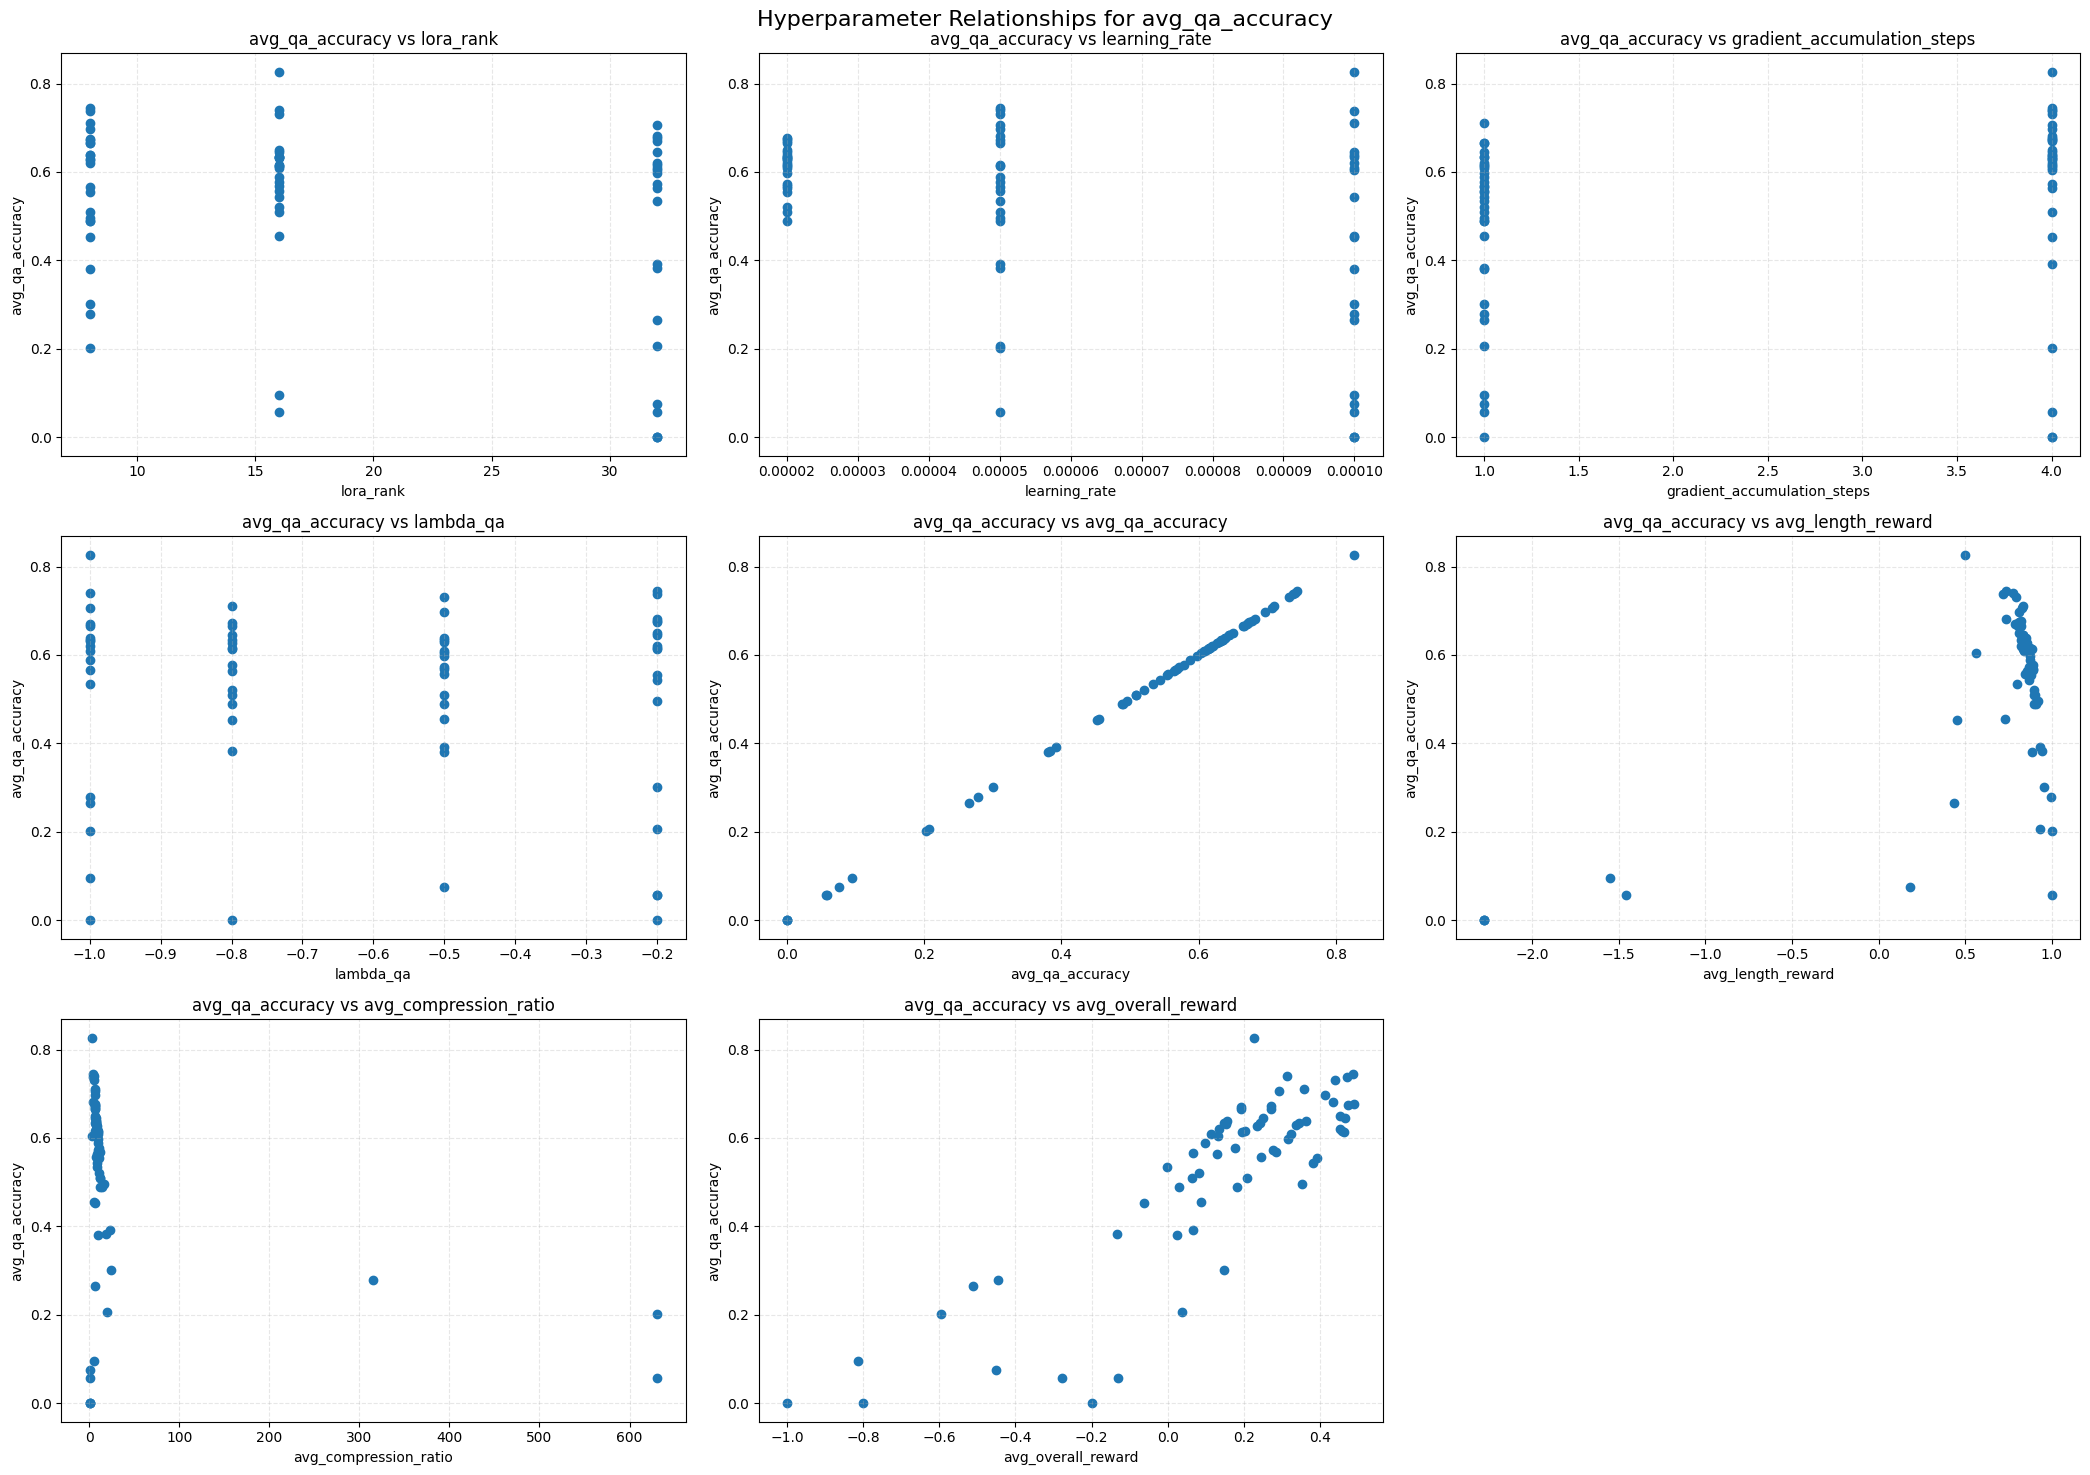

In [28]:
metrics = [
    "avg_compression_ratio",
    "avg_overall_reward",
    "avg_qa_accuracy"
]

numeric_hps = ['lora_rank','learning_rate', 'gradient_accumulation_steps', 'lambda_qa', 'avg_qa_accuracy', 'avg_length_reward', 'avg_compression_ratio', 'avg_overall_reward']


for metric in metrics:
    n = len(numeric_hps)
    cols = 3
    rows = math.ceil(n / cols)
    
    fig, axes = plt.subplots(rows, cols, figsize=(7*cols, 5*rows))
    axes = axes.flatten()

    for i, hp in enumerate(numeric_hps):
        ax = axes[i]
        ax.scatter(results_df[hp], results_df[metric])
        ax.set_xlabel(hp)
        ax.set_ylabel(metric)
        ax.set_title(f"{metric} vs {hp}")
        ax.grid(True, linestyle="--", alpha=0.3)

    # hide unused subplots
    for j in range(i+1, len(axes)):
        axes[j].axis("off")

    fig.suptitle(f"Hyperparameter Relationships for {metric}", fontsize=16)
    plt.tight_layout()
    plt.show()


In [8]:
results_df.sort_values(by="avg_qa_accuracy", ascending=False).iloc[:2]["experiment_name"].to_list()[1]

'sweep_learning_rate_5eneg05_lora_rank_8_gradient_accumulation_steps_4_lambda_neg0p200'